<a href="https://colab.research.google.com/github/ankitarchoudhary/IBM-Data-Science-Capstone/blob/main/Phase3_EDA_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3: Exploratory Data Analysis (EDA) with Data Visualization

This phase visualizes patterns in the data to understand what influences landing success:
relationships between flight number, launch site, payload mass, orbit type, and the year-over-year
success trend.


## Load the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

df = pd.read_csv('spacex_wrangled.csv')
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


**Explanation:**
- `matplotlib.pyplot` and `seaborn` are the two libraries used for plotting charts.
- `%matplotlib inline` is a Colab/Jupyter command that makes charts display directly below the
  code cell that created them.
- `sns.set_style('whitegrid')` applies a clean background style with light gridlines to all plots.
- `pd.read_csv('spacex_wrangled.csv')` loads the cleaned dataset from Phase 2.

## Flight Number vs. Launch Site

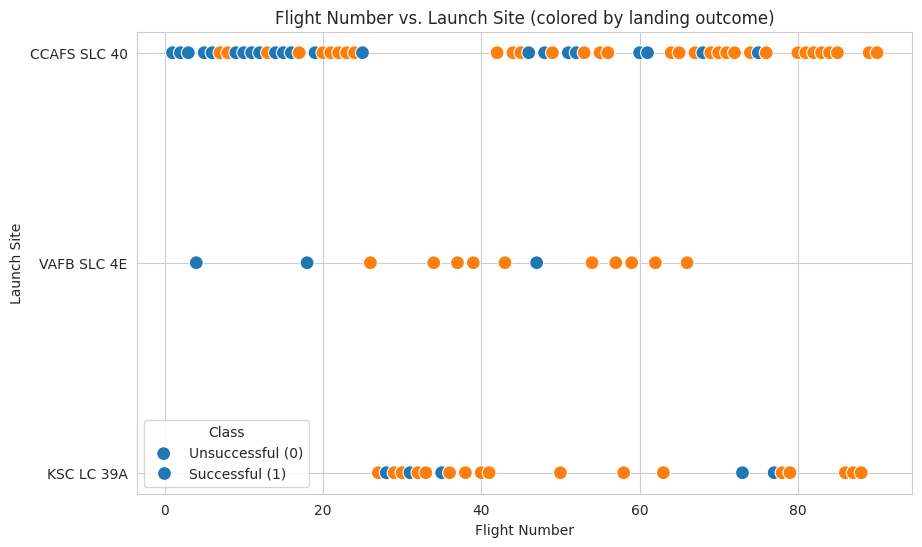

In [2]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='FlightNumber', y='LaunchSite', hue='Class', s=100)
plt.xlabel('Flight Number')
plt.ylabel('Launch Site')
plt.title('Flight Number vs. Launch Site (colored by landing outcome)')
plt.legend(title='Class', labels=['Unsuccessful (0)', 'Successful (1)'])
plt.show()

**Explanation:**
- `sns.scatterplot(...)` plots each launch as a point: x-axis is the flight number (chronological
  order), y-axis is the launch site, and `hue='Class'` colors each point by whether the landing
  succeeded.
- `s=100` sets the point size, making them easier to see.
- This chart shows whether success became more common at higher flight numbers (i.e. as time went
  on), and whether that pattern differs by launch site.

## Payload Mass vs. Launch Site

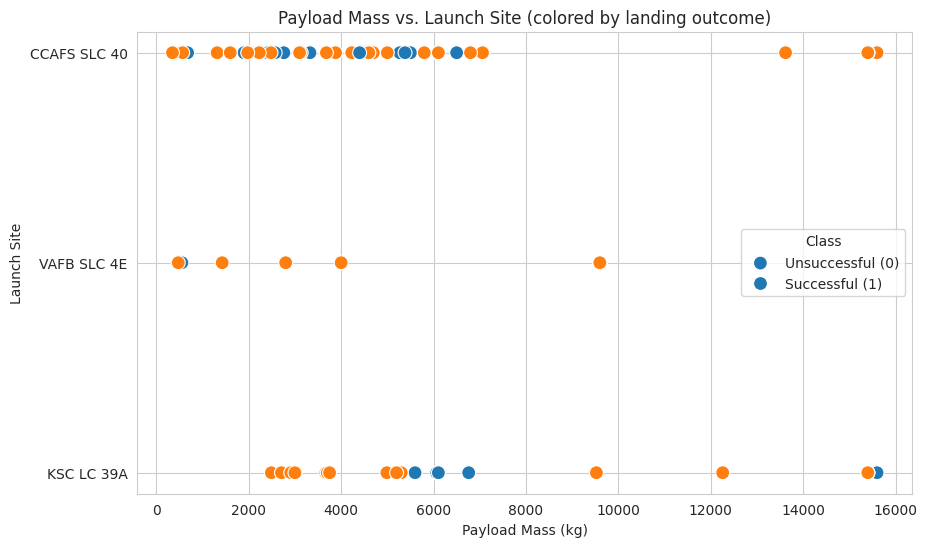

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PayloadMass', y='LaunchSite', hue='Class', s=100)
plt.xlabel('Payload Mass (kg)')
plt.ylabel('Launch Site')
plt.title('Payload Mass vs. Launch Site (colored by landing outcome)')
plt.legend(title='Class', labels=['Unsuccessful (0)', 'Successful (1)'])
plt.show()

**Explanation:** same type of chart as above, but with payload mass on the x-axis instead of
flight number. This shows whether heavier payloads are associated with more or fewer successful
landings at each site.

## Success Rate by Orbit Type

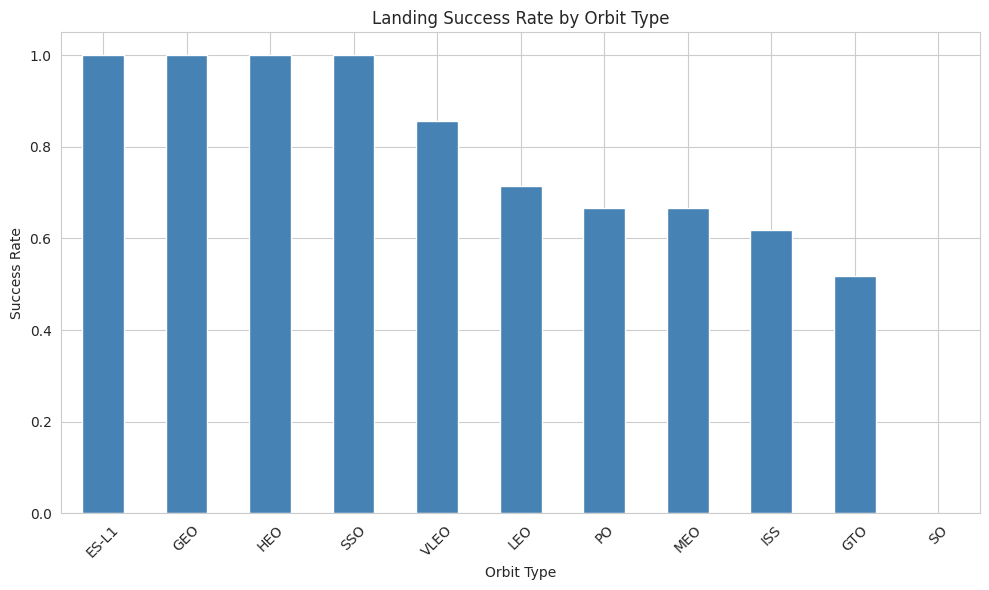

,Class
Orbit,
ES-L1,1.000000
GEO,1.000000
HEO,1.000000
SSO,1.000000
VLEO,0.857143
LEO,0.714286
PO,0.666667
MEO,0.666667
ISS,0.619048


In [4]:
orbit_success = df.groupby('Orbit')['Class'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
orbit_success.plot(kind='bar', color='steelblue')
plt.xlabel('Orbit Type')
plt.ylabel('Success Rate')
plt.title('Landing Success Rate by Orbit Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

orbit_success

**Explanation:**
- `df.groupby('Orbit')['Class'].mean()` groups the data by orbit type, then computes the average
  of `Class` for each group. Since `Class` is 0/1, this average is exactly the success rate for
  that orbit.
- `.sort_values(ascending=False)` orders the orbits from highest to lowest success rate.
- `.plot(kind='bar', ...)` draws this as a bar chart, making it easy to compare orbits visually.

## Flight Number vs. Orbit Type

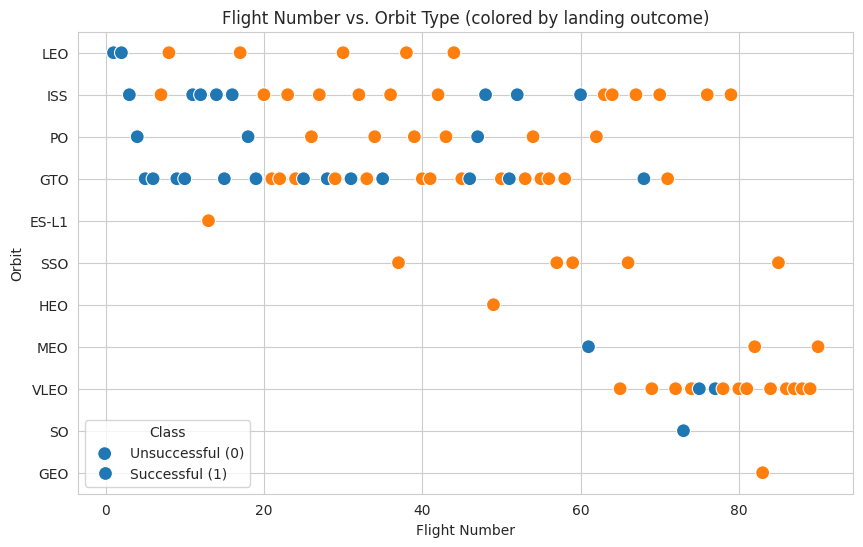

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='FlightNumber', y='Orbit', hue='Class', s=100)
plt.xlabel('Flight Number')
plt.ylabel('Orbit')
plt.title('Flight Number vs. Orbit Type (colored by landing outcome)')
plt.legend(title='Class', labels=['Unsuccessful (0)', 'Successful (1)'])
plt.show()

**Explanation:** shows whether success within a specific orbit type is related to how early
or late (by flight number) the launch happened - for example, whether a given orbit type became
more reliable over time.

## Payload Mass vs. Orbit Type

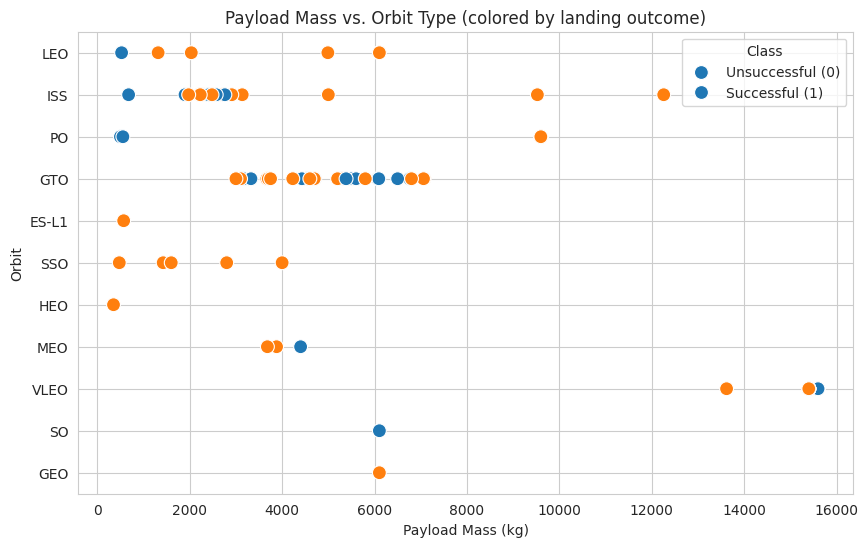

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PayloadMass', y='Orbit', hue='Class', s=100)
plt.xlabel('Payload Mass (kg)')
plt.ylabel('Orbit')
plt.title('Payload Mass vs. Orbit Type (colored by landing outcome)')
plt.legend(title='Class', labels=['Unsuccessful (0)', 'Successful (1)'])
plt.show()

**Explanation:** shows how payload mass and orbit type interact - for example, whether heavy
payloads only succeed in certain orbits.

## Launch Success Yearly Trend

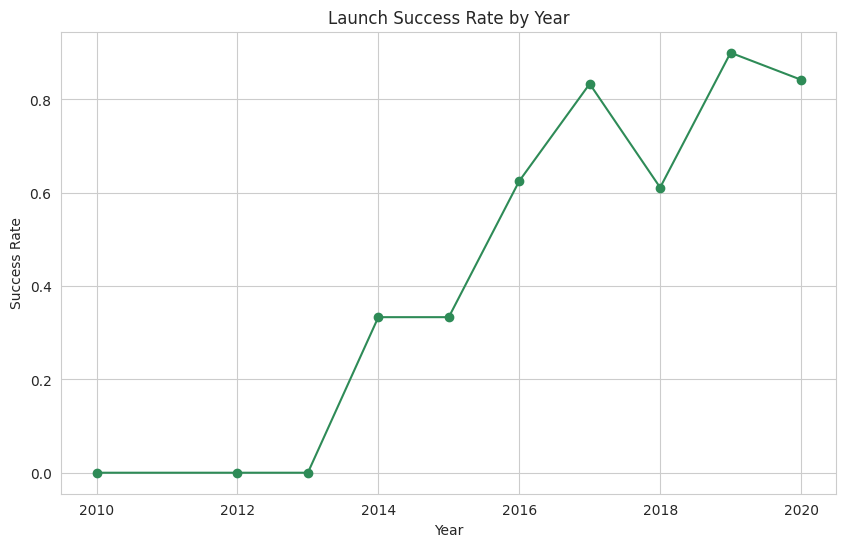

,Class
Year,
2010,0.000000
2012,0.000000
2013,0.000000
2014,0.333333
2015,0.333333
2016,0.625000
2017,0.833333
2018,0.611111
2019,0.900000


In [7]:
df['Year'] = pd.to_datetime(df['Date']).dt.year

yearly_success = df.groupby('Year')['Class'].mean()

plt.figure(figsize=(10, 6))
yearly_success.plot(kind='line', marker='o', color='seagreen')
plt.xlabel('Year')
plt.ylabel('Success Rate')
plt.title('Launch Success Rate by Year')
plt.grid(True)
plt.show()

yearly_success

**Explanation:**
- `pd.to_datetime(df['Date']).dt.year` converts the text `Date` column into a proper date type,
  then extracts just the year.
- Grouping by `Year` and averaging `Class` gives the success rate for each year.
- The line chart shows whether SpaceX's landing success rate improved over time - a key question
  this project aims to answer.

## Boolean Feature Distributions: GridFins, Reused, Legs

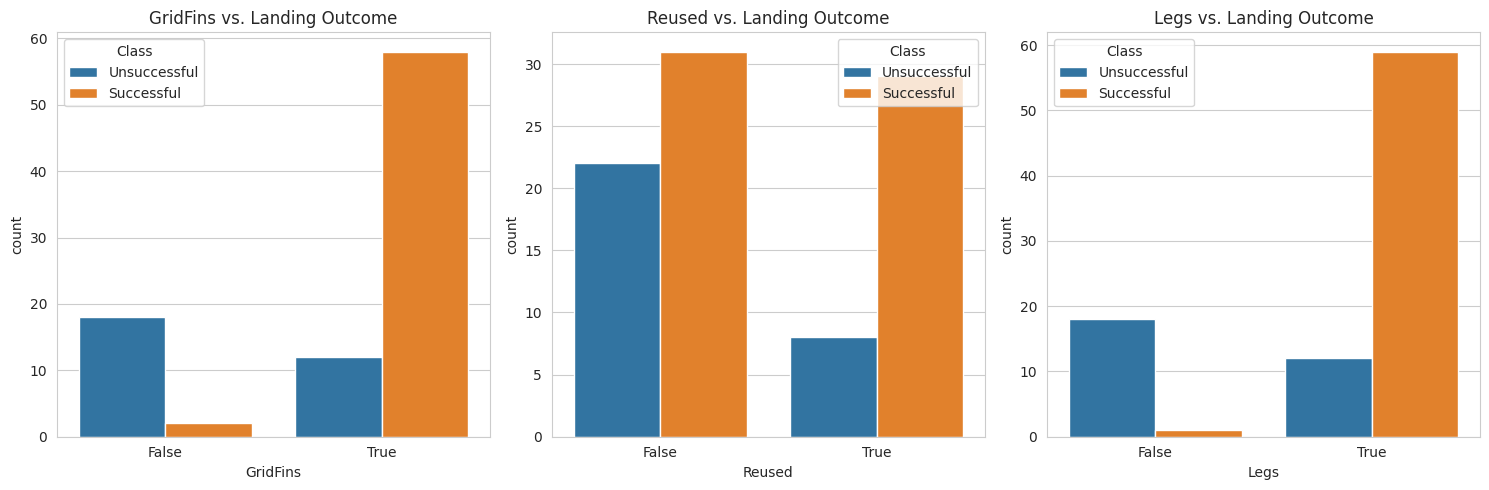

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['GridFins', 'Reused', 'Legs']):
    sns.countplot(data=df, x=col, hue='Class', ax=ax)
    ax.set_title(f'{col} vs. Landing Outcome')
    ax.legend(title='Class', labels=['Unsuccessful', 'Successful'])

plt.tight_layout()
plt.show()

**Explanation:**
- `plt.subplots(1, 3, ...)` creates a row of 3 side-by-side charts.
- `sns.countplot(...)` counts how many launches fall into each combination of the feature
  (True/False) and landing outcome (0/1).
- These charts help spot whether having grid fins, a reused booster, or landing legs is
  associated with a higher success rate.

## Correlation Between Numeric Features

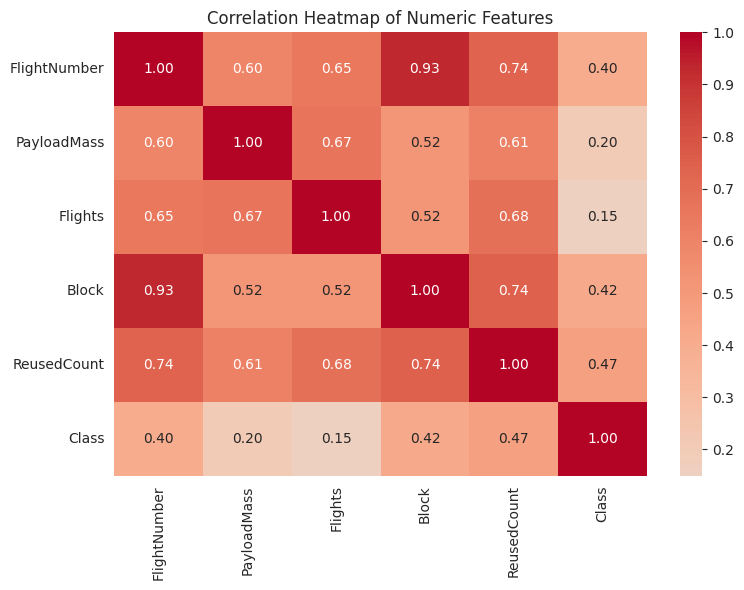

In [9]:
numeric_cols = ['FlightNumber', 'PayloadMass', 'Flights', 'Block', 'ReusedCount', 'Class']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

**Explanation:**
- `.corr()` computes the pairwise correlation coefficient between each pair of numeric columns,
  ranging from -1 (strong negative relationship) to +1 (strong positive relationship).
- `sns.heatmap(...)` displays this correlation matrix as a color-coded grid, with `annot=True`
  printing the actual numbers on each cell.
- The `Class` row/column is the most important one to look at here - it shows which numeric
  features are most (positively or negatively) related to landing success.